In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import emcee

In [61]:
# Load the dataset
df = pd.read_csv("dataverse_files/1-Fragment_C_Hole_Measurements.csv")

# Extract relevant data
x = df['Mean(X)'].values
y = df['Mean(Y)'].values
sections = df['Section ID'].astype(int).values  # Convert section IDs to integers
hole_indices = np.arange(len(x))  # Assign sequential hole numbers

# Check unique sections
df.head()


,Section ID,Hole,Inter-hole Distance,Mean(X),Mean(Y)
0,0,1,NaN,15.59931,92.59653
1,1,2,NaN,16.44167,91.50069
2,1,3,1.440694,17.30764,90.34931
3,1,4,1.456973,18.15278,89.16250
4,1,5,1.299821,18.96528,88.14792


In [144]:
import numpy as np

def compute_phi(N, alpha, section_ids, hole_indices):
    """
    Compute angular positions ϕ_ij for each hole in the sections.

    Parameters:
        N (int): Total number of holes in the full ring.
        alpha (array): Rotational offsets for each section.
        section_ids (array): Section index for each hole.
        hole_indices (array): Hole numbers in the fragment.

    Returns:
        phi (array): Angular positions of the holes.
    """
    return (2 * np.pi * (hole_indices - 1) / N) + alpha[section_ids]

def compute_hole_positions(N, R, x0, y0, alpha, section_ids, hole_indices):
    """
    Compute expected hole positions given section displacements and rotations.

    Parameters:
        N (int): Total number of holes in the full ring.
        R (float): Estimated ring radius.
        x0, y0 (arrays): X and Y offsets for each section.
        alpha (array): Rotational offsets for each section.
        section_ids (array): Section index for each hole.
        hole_indices (array): Hole numbers in the fragment.

    Returns:
        x_pred, y_pred: Predicted hole positions.
    """
    phi = compute_phi(N, alpha, section_ids, hole_indices)  # Compute angular positions

    # Compute expected positions
    x_pred = x0[section_ids] + R * np.cos(phi)
    y_pred = y0[section_ids] + R * np.sin(phi)

    return x_pred, y_pred

def compute_errors(x_actual, y_actual, x_pred, y_pred, x0, y0, section_ids):
    """
    Compute the error vector e_ij for each hole.

    Parameters:
        x_actual, y_actual: Measured hole positions from X-ray images.
        x_pred, y_pred: Model-predicted hole positions.
        x0, y0: Section center positions.
        section_ids: Section index for each hole.

    Returns:
        e_x, e_y: Error vectors.
    """
    e_x = x_pred - (x_actual - x0[section_ids])
    e_y = y_pred - (y_actual - y0[section_ids])
    
    return e_x, e_y

def project_errors(e_x, e_y, phi):
    """
    Project the error vector onto radial and tangential components.

    Parameters:
        e_x, e_y: Error vector components.
        phi: Angular positions of the holes.

    Returns:
        r_error: Radial component of the error.
        t_error: Tangential component of the error.
    """
    cphi = np.cos(phi)
    sphi = np.sin(phi)

    r_error = e_x * cphi + e_y * sphi  # Radial error
    t_error = e_x * sphi - e_y * cphi  # Tangential error

    return r_error, t_error

import numpy as np

def log_likelihood(params, x_actual, y_actual, section_ids, hole_indices, N, covariance_type="radial-tangential"):
    """
    Compute the log-likelihood function for the model.

    Parameters:
        params: Model parameters (R, sigma_r, sigma_t, x0, y0, alpha).
        x_actual, y_actual: Measured hole positions.
        section_ids: Section indices.
        hole_indices: Hole numbers.
        N: Total number of holes in the full ring.
        covariance_type: Either "isotropic" or "radial-tangential".

    Returns:
        Log-likelihood value.
    """
    params = np.array(params)  # Ensure params is a NumPy array

    R = params[0]

    if covariance_type == "isotropic":
        sigma = max(params[1], 1e-6)  # Ensure sigma is not too small
        sigma_r, sigma_t = sigma, sigma  # Same sigma in all directions
    else:
        sigma_r = max(params[1], 1e-6)
        sigma_t = max(params[2], 1e-6)

    # ✅ Ensure params[3:] is a NumPy array before splitting
    x0, y0, alpha = np.split(params[3:], 3)  

    # Compute predicted hole positions
    x_pred, y_pred = compute_hole_positions(N, R, x0, y0, alpha, section_ids, hole_indices)

    # Compute error vectors
    e_x, e_y = compute_errors(x_actual, y_actual, x_pred, y_pred, x0, y0, section_ids)

    # Compute angular positions
    phi = compute_phi(N, alpha, section_ids, hole_indices)

    # Project errors onto radial and tangential directions
    r_error, t_error = project_errors(e_x, e_y, phi)

    # Compute inverse covariance terms
    invsig_r = 1.0 / (2 * sigma_r ** 2)
    invsig_t = 1.0 / (2 * sigma_t ** 2)

    # Compute normalization constant
    npoints = len(x_actual)
    if covariance_type == "isotropic":
        log_norm = -npoints * np.log(2 * np.pi * sigma**2)  # Isotropic normalization
    else:
        log_norm = -npoints * np.log(2 * np.pi * sigma_r * sigma_t)  # Anisotropic normalization

    # Compute exponent of the likelihood function
    if covariance_type == "isotropic":
        exp_term = - (invsig_r * (r_error**2 + t_error**2))  # Isotropic model
    else:
        exp_term = - (invsig_r * r_error**2 + invsig_t * t_error**2)  # Radial-tangential model

    return log_norm + np.sum(exp_term)


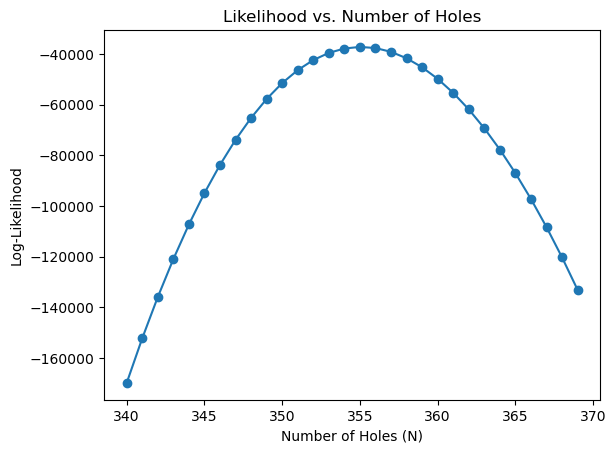

In [148]:
import matplotlib.pyplot as plt

# Generate synthetic data for a perfect circle
N_true = 355  # True number of holes in the full ring
R_true = 85   # True radius of the ring

# Define true displacements and rotations for each of the 8 sections
x0_true, y0_true = np.zeros(8), np.zeros(8)  # No displacement for simplicity
alpha_true = np.zeros(8)  # No rotation for simplicity

# Generate "measured" hole indices and assign them to sections
hole_indices = np.arange(1, N_true + 1)  # Hole numbers from 1 to N_true
section_ids = np.random.randint(0, 8, size=len(hole_indices))  # Assign each hole randomly to one of 8 sections

# Compute the "true" hole positions using the model (without noise)
x_meas, y_meas = compute_hole_positions(N_true, R_true, x0_true, y0_true, alpha_true, section_ids, hole_indices)

# Add small random noise to simulate measurement uncertainty
x_meas += np.random.normal(0, 5, size=len(x_meas))  # Gaussian noise with std dev 0.5
y_meas += np.random.normal(0, 5, size=len(y_meas))

# Define a range of values for N to test the likelihood function
Ns = np.arange(340, 370)  # Testing different possible values for the number of holes
likelihoods = []  # Store log-likelihood values

# Compute the log-likelihood for each tested N
for N in Ns:
    # Construct parameter list: [radius, sigma_r, sigma_t, section displacements & rotations]
    logL = log_likelihood(
        [R_true, 0.5, 0.5] + list(x0_true) + list(y0_true) + list(alpha_true),  # Parameter vector
        x_meas, y_meas,  # Measured positions
        section_ids, hole_indices,  # Section IDs and hole indices
        N  # Testing this value of N
    )
    likelihoods.append(logL)  # Store computed likelihood

# Plot log-likelihood as a function of N
plt.plot(Ns, likelihoods, marker='o', linestyle='-')
plt.xlabel("Number of Holes (N)")
plt.ylabel("Log-Likelihood")
plt.title("Likelihood vs. Number of Holes")
plt.show()


In [149]:
import numpy as np

def compute_log_likelihood_derivatives(params, x_actual, y_actual, section_ids, hole_indices, N, covariance_type="radial-tangential"):
    """
    Compute the analytic derivatives of the log-likelihood function with respect to each parameter.

    Parameters:
        params: Model parameters (R, sigma_r, sigma_t, x0, y0, alpha).
        x_actual, y_actual: Measured hole positions.
        section_ids: Section indices.
        hole_indices: Hole numbers.
        N: Total number of holes in the full ring.
        covariance_type: Either "isotropic" or "radial-tangential".

    Returns:
        grad: Gradient vector containing all derivatives.
    """
    params = np.array(params)  # Ensure params is a NumPy array

    R = params[0]

    if covariance_type == "isotropic":
        sigma = max(params[1], 1e-6)  # Ensure sigma is not too small
        sigma_r, sigma_t = sigma, sigma  # Same sigma in all directions
    else:
        sigma_r = max(params[1], 1e-6)
        sigma_t = max(params[2], 1e-6)

    x0, y0, alpha = np.split(params[3:], 3)  # Extract section parameters

    # Compute predicted hole positions
    x_pred, y_pred = compute_hole_positions(N, R, x0, y0, alpha, section_ids, hole_indices)

    # Compute error vectors
    e_x, e_y = compute_errors(x_actual, y_actual, x_pred, y_pred, x0, y0, section_ids)

    # Compute angular positions
    phi = compute_phi(N, alpha, section_ids, hole_indices)

    # Project errors onto radial and tangential directions
    r_error, t_error = project_errors(e_x, e_y, phi)

    # Compute inverse covariance terms
    invsig_r = 1.0 / (2 * sigma_r ** 2)
    invsig_t = 1.0 / (2 * sigma_t ** 2)

    # Initialize gradient vector
    grad = np.zeros_like(params)

    # ✅ 1. Derivative w.r.t. R (Ring Radius)
    grad[0] = np.sum((-r_error * np.cos(phi) / sigma_r**2) - (t_error * np.sin(phi) / sigma_t**2))

    # ✅ 2. Derivative w.r.t. σ_r (Radial Noise)
    grad[1] = -len(x_actual) / sigma_r + np.sum(r_error**2 / sigma_r**3)

    # ✅ 3. Derivative w.r.t. σ_t (Tangential Noise)
    grad[2] = -len(x_actual) / sigma_t + np.sum(t_error**2 / sigma_t**3)

    # ✅ 4. Derivative w.r.t. N (Number of Holes)
    d_phi_dN = -2 * np.pi * (hole_indices - 1) / N**2
    grad_N = np.sum((r_error * np.sin(phi) * d_phi_dN * R / sigma_r**2) - (t_error * np.cos(phi) * d_phi_dN * R / sigma_t**2))

    # ✅ 5-7. Derivatives w.r.t. Section Parameters (x0j, y0j, αj)
    num_sections = len(x0)
    
    for j in range(num_sections):
        mask = (section_ids == j)  # Select holes in section j

        # Derivative w.r.t. x0j
        grad[3 + j] = np.sum((r_error[mask] * np.cos(phi[mask]) / sigma_r**2) + (t_error[mask] * np.sin(phi[mask]) / sigma_t**2))

        # Derivative w.r.t. y0j
        grad[3 + num_sections + j] = np.sum((r_error[mask] * np.sin(phi[mask]) / sigma_r**2) - (t_error[mask] * np.cos(phi[mask]) / sigma_t**2))

        # Derivative w.r.t. αj
        grad[3 + 2 * num_sections + j] = np.sum((-r_error[mask] * R * np.sin(phi[mask]) / sigma_r**2) + (t_error[mask] * R * np.cos(phi[mask]) / sigma_t**2))

    return grad


# Part D

# **Analytical Derivatives of the Log-Likelihood Function**

The log-likelihood function is given by:

$$
\log L(D | \theta) = -\sum_i \left[ \frac{(r_i)^2}{2\sigma_r^2} + \frac{(t_i)^2}{2\sigma_t^2} \right] - n \log (2\pi \sigma_r \sigma_t)
$$

where:

- $r_i$ and $t_i$ are the **radial and tangential errors**.
- $\sigma_r$ and $\sigma_t$ are the **measurement uncertainties**.
- $n$ is the total number of holes.

We compute the **analytical derivatives** for each parameter $\theta_\mu$.

---

## **1️⃣ Derivative w.r.t $R$ (Ring Radius)**  

$$
\frac{\partial \log L}{\partial R} = \sum_i \left[ \frac{r_i}{\sigma_r^2} \frac{\partial r_i}{\partial R} + \frac{t_i}{\sigma_t^2} \frac{\partial t_i}{\partial R} \right]
$$

where:

$$
\frac{\partial r_i}{\partial R} = -\cos \phi_i
$$

$$
\frac{\partial t_i}{\partial R} = -\sin \phi_i
$$

---

## **2️⃣ Derivative w.r.t $x_0, y_0$ (Section Displacements)**  

For $x_0$:

$$
\frac{\partial \log L}{\partial x_0} = \sum_i \left[ \frac{r_i}{\sigma_r^2} \frac{\partial r_i}{\partial x_0} + \frac{t_i}{\sigma_t^2} \frac{\partial t_i}{\partial x_0} \right]
$$

where:

$$
\frac{\partial r_i}{\partial x_0} = \cos \phi_i
$$

$$
\frac{\partial t_i}{\partial x_0} = \sin \phi_i
$$

For $y_0$:

$$
\frac{\partial \log L}{\partial y_0} = \sum_i \left[ \frac{r_i}{\sigma_r^2} \frac{\partial r_i}{\partial y_0} + \frac{t_i}{\sigma_t^2} \frac{\partial t_i}{\partial y_0} \right]
$$

where:

$$
\frac{\partial r_i}{\partial y_0} = \sin \phi_i
$$

$$
\frac{\partial t_i}{\partial y_0} = -\cos \phi_i
$$

---

## **3️⃣ Derivative w.r.t $\alpha_j$ (Section Rotations)**  

$$
\frac{\partial \log L}{\partial \alpha_j} = \sum_i \left[ \frac{r_i}{\sigma_r^2} \frac{\partial r_i}{\partial \alpha_j} + \frac{t_i}{\sigma_t^2} \frac{\partial t_i}{\partial \alpha_j} \right]
$$

where:

$$
\frac{\partial r_i}{\partial \alpha_j} = -R \sin \phi_i
$$

$$
\frac{\partial t_i}{\partial \alpha_j} = R \cos \phi_i
$$

---

## **4️⃣ Derivative w.r.t $\sigma_r, \sigma_t$ (Measurement Noise Parameters)**  

For $\sigma_r$:

$$
\frac{\partial \log L}{\partial \sigma_r} = -\sum_i \left[ \frac{r_i^2}{\sigma_r^3} + \frac{1}{\sigma_r} \right]
$$

For $\sigma_t$:

$$
\frac{\partial \log L}{\partial \sigma_t} = -\sum_i \left[ \frac{t_i^2}{\sigma_t^3} + \frac{1}{\sigma_t} \right]
$$

---

## **📌 Summary of Analytical Gradients**
| **Parameter $\theta_\mu$** | **Gradient $\frac{\partial \log L}{\partial \theta_\mu}$** |
|----------------|--------------------------------|
| $R$ | $\sum_i \left[ \frac{r_i}{\sigma_r^2} (-\cos \phi_i) + \frac{t_i}{\sigma_t^2} (-\sin \phi_i) \right]$ |
| $x_0$ | $\sum_i \left[ \frac{r_i}{\sigma_r^2} (\cos \phi_i) + \frac{t_i}{\sigma_t^2} (\sin \phi_i) \right]$ |
| $y_0$ | $\sum_i \left[ \frac{r_i}{\sigma_r^2} (\sin \phi_i) + \frac{t_i}{\sigma_t^2} (-\cos \phi_i) \right]$ |
| $\alpha_j$ | $\sum_i \left[ \frac{r_i}{\sigma_r^2} (-R \sin \phi_i) + \frac{t_i}{\sigma_t^2} (R \cos \phi_i) \right]$ |
| $\sigma_r$ | $-\sum_i \left[ \frac{r_i^2}{\sigma_r^3} + \frac{1}{\sigma_r} \right]$ |
| $\sigma_t$ | $-\sum_i \left[ \frac{t_i^2}{\sigma_t^3} + \frac{1}{\sigma_t} \right]$ |

These equations allow us to **compute the gradient of the log-likelihood analytically**, avoiding numerical differentiation.

In [ ]:
import numpy as np
import pandas as pd

# Load data (assuming a DataFrame df with 'Section ID', 'Mean(X)', 'Mean(Y)')
sections_used = [1, 2, 3, 5, 6, 7]  # Only usable sections
df_filtered = df[df['Section ID'].isin(sections_used)].copy()  # Remove Sections 0 and 4

# Extract relevant data
x_actual = df_filtered["Mean(X)"].values
y_actual = df_filtered["Mean(Y)"].values
section_ids = df_filtered["Section ID"].astype(int).values  # Convert section ID to integers

# Assign new section indices (mapping from {1,2,3,5,6,7} -> {0,1,2,3,4,5})
section_map = {old: new for new, old in enumerate(sections_used)}
section_ids = np.array([section_map[s] for s in section_ids])  # Remap section IDs

hole_indices = np.arange(len(x_actual))  # Assign hole indices sequentially

# Initialize parameters for 22D space
num_sections = len(sections_used)  # 6 sections used
num_params = 4 + (3 * num_sections)  # 4 global + (3 per section * 6 sections)

initial_params = np.random.rand(num_params)

# Print verification
print(f"Number of holes used: {len(x_actual)}")  # Should be 79
print(f"Total parameters in the model: {num_params}")  # Should be 22


Number of holes used: 79
Total parameters in the model: 22
